
### Analiza statystyczna


In [16]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt

import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [17]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
cyp2d6_veith    13130
cyp3a4_veith    12328
cyp2c9_veith    12092
Name: count, dtype: int64
Średnia liczba zadań na smiles: 2.33


,task,cyp2c9_veith,cyp2d6_veith,cyp3a4_veith,mean,count,std
0,cyp2c9_veith,12092,9750,9265,0.334519,12092,0.471841
1,cyp2d6_veith,9750,13130,9932,0.191470,13130,0.393473
2,cyp3a4_veith,9265,9932,12328,0.414504,12328,0.492656


In [18]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

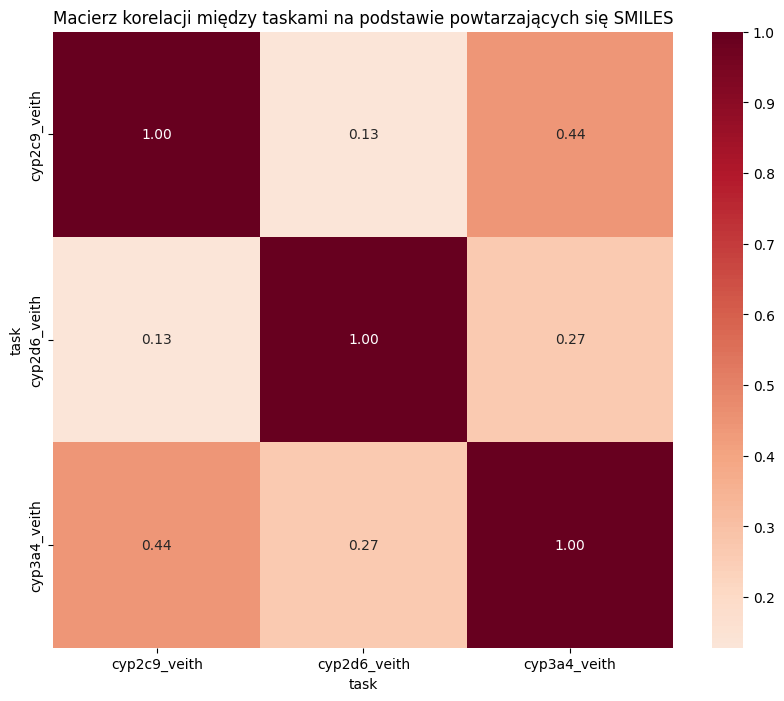

In [19]:
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

NaN wynika z braku wariancji w części wspólnej hia_hou (absorbcja) i bbb_martins (dystrybucja). W każdym przypadku jeśli badano oba związki to absorbcja wynosiła True.

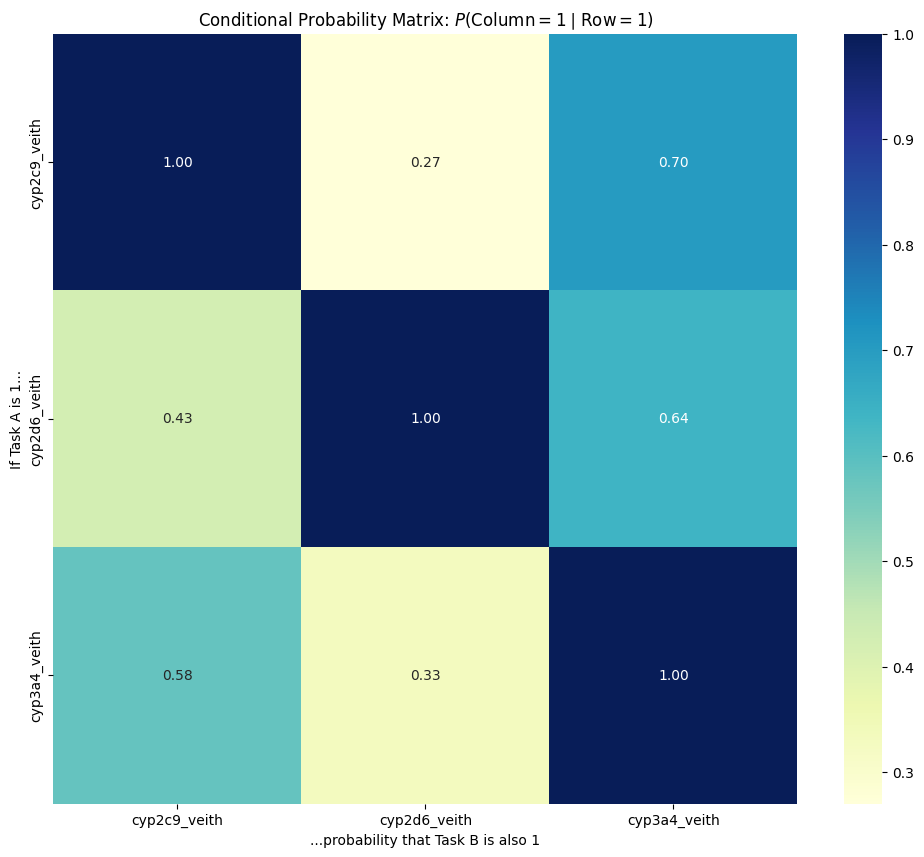

In [20]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

### Random Forest

In [21]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)




summary_df


--- Top 15 najważniejszych cech dla cyp2c9_veith ---
            feature  importance
            MolLogP    0.044035
       FractionCSP3    0.028960
              MolMR    0.026750
              MolWt    0.024472
          LabuteASA    0.024191
           BalabanJ    0.018212
                qed    0.017185
     HeavyAtomCount    0.016545
   NumAromaticRings    0.016247
   MaxPartialCharge    0.015991
NumValenceElectrons    0.015807
               TPSA    0.014923
MaxAbsPartialCharge    0.013538
  NumSaturatedRings    0.009755
  NumRotatableBonds    0.009674

--- Top 15 najważniejszych cech dla cyp2d6_veith ---
            feature  importance
   MaxPartialCharge    0.029700
               TPSA    0.028883
           BalabanJ    0.023421
            MolLogP    0.021378
              MolMR    0.017278
          LabuteASA    0.014830
              MolWt    0.014190
            NOCount    0.014145
                qed    0.014012
MaxAbsPartialCharge    0.013871
       FractionCSP3    0.012

,task,auc,acc,f1
0,cyp2c9_veith,0.896691,0.817204,0.708827
1,cyp2d6_veith,0.873927,0.872430,0.537931
2,cyp3a4_veith,0.885595,0.797242,0.740933



SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.

### MTL model

In [ ]:
import numpy as np
import torch
from TODO.zadanie1.michal.mtl_utils import MTLDataset, MTLNet, train_epoch, evaluate
from torch.utils.data import DataLoader

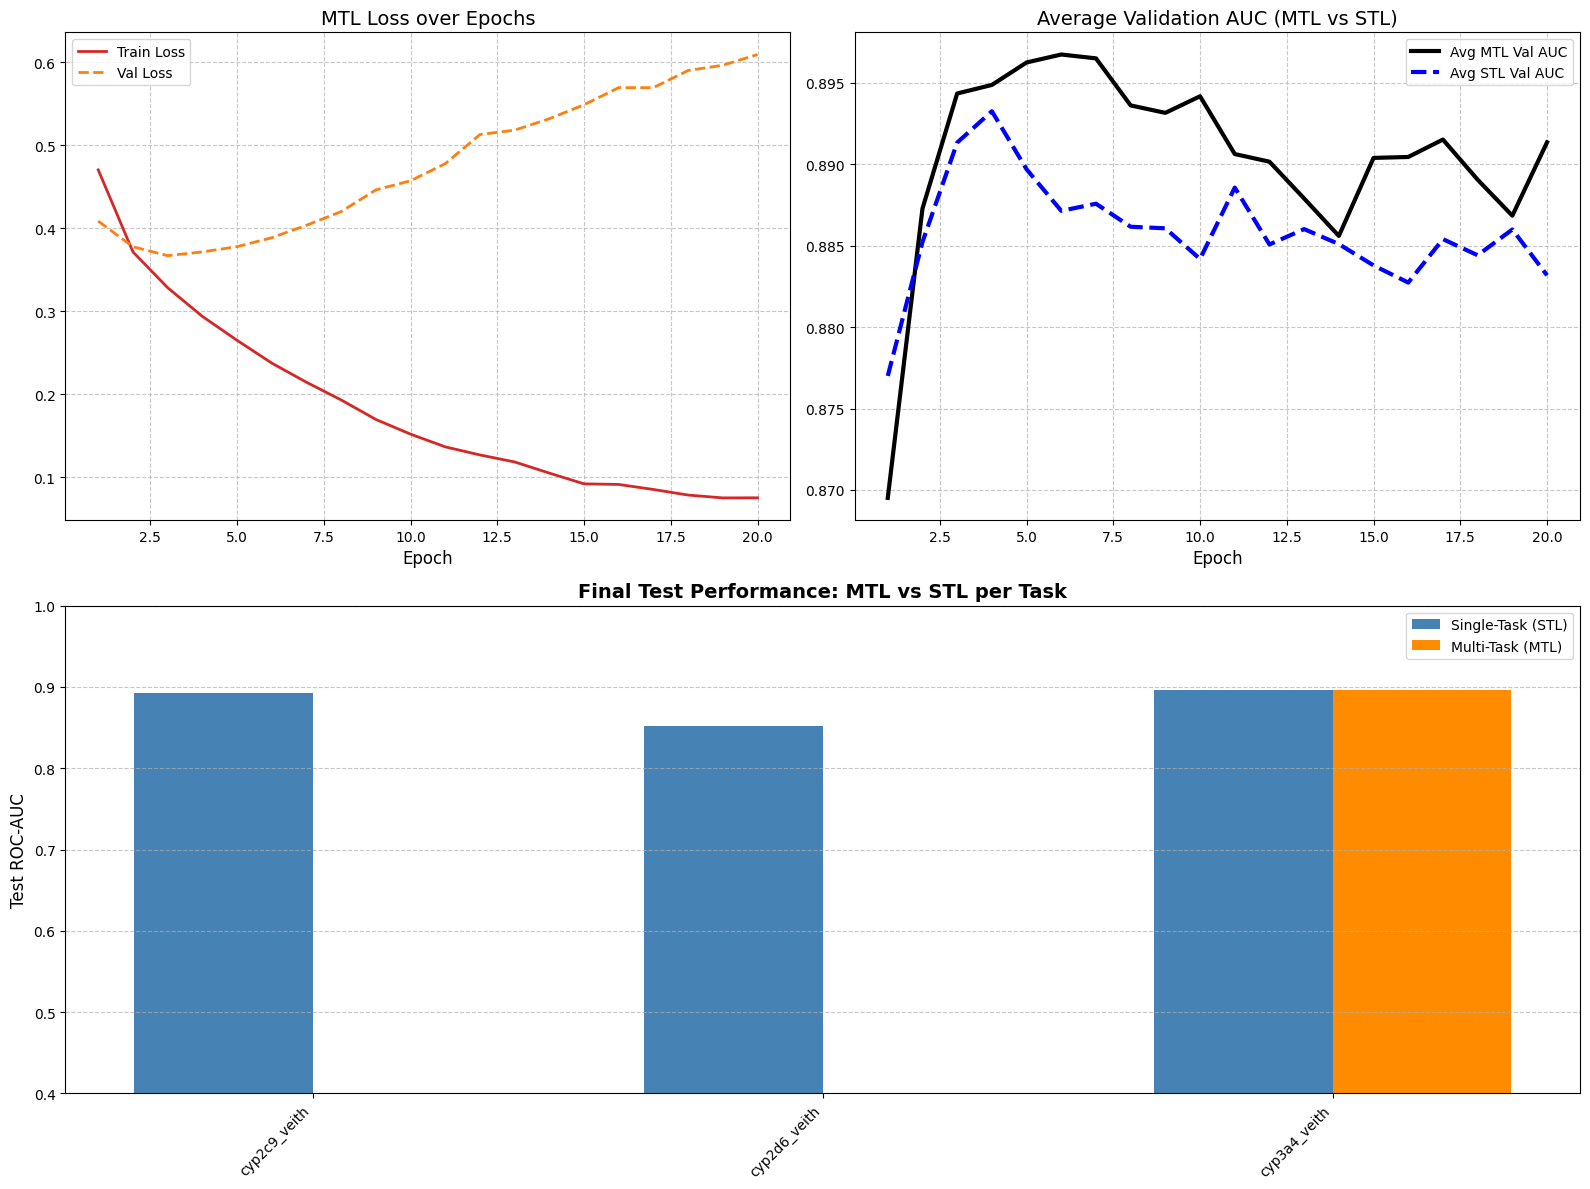

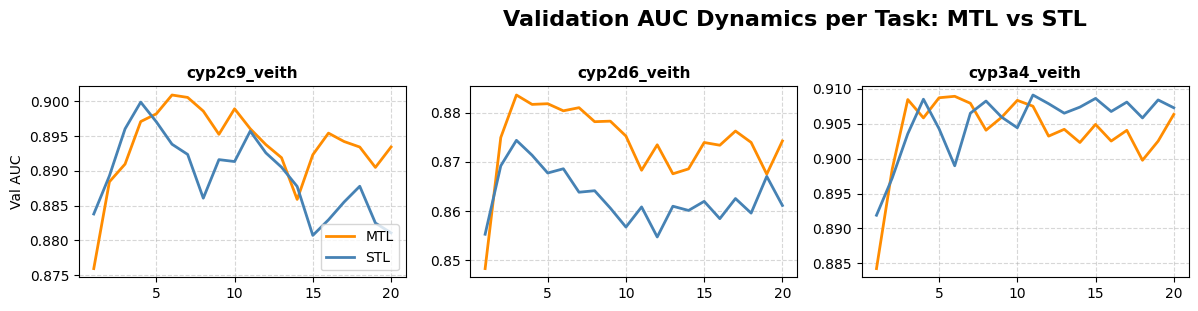

In [26]:

# =====================================================================
# 1. TRENING MODELI SINGLE-TASK (STL) - Używając tej samej klasy MTLNet
# =====================================================================
print("\n" + "="*50)
print(" ROZPOCZYNAMY EKSPERYMENTY SINGLE-TASK (STL)")
print("="*50)

# Struktury na wyniki STL
stl_val_history = {task: [] for task in tasks}
stl_test_aucs = {}

# UWAGA: Upewnij się, że masz już wyliczone test_aucs dla modelu MTL!
# _, test_aucs_mtl = evaluate(model, test_loader, device, tasks)

for i, task_name in enumerate(tasks):
    print(f"Trenowanie STL (1 głowica) dla: {task_name}...")

    # Wycinamy tylko jedną kolumnę (zachowując kształt 2D np. [N, 1])
    y_train_stl = y_all[train_idx][:, i:i+1]
    mask_train_stl = mask_all[train_idx][:, i:i+1]

    y_val_stl = y_all[val_idx][:, i:i+1]
    mask_val_stl = mask_all[val_idx][:, i:i+1]

    y_test_stl = y_all[test_idx][:, i:i+1]
    mask_test_stl = mask_all[test_idx][:, i:i+1]

    # Loadery dla pojedynczego tasku
    train_loader_stl = DataLoader(MTLDataset(X_all[train_idx], y_train_stl, mask_train_stl), batch_size=128, shuffle=True)
    val_loader_stl = DataLoader(MTLDataset(X_all[val_idx], y_val_stl, mask_val_stl), batch_size=128)
    test_loader_stl = DataLoader(MTLDataset(X_all[test_idx], y_test_stl, mask_test_stl), batch_size=128)

    # Inicjalizacja TWOJEGO modelu (tylko z jedną głowicą)
    model_stl = MTLNet(X_all.shape[1], 1).to(device)
    opt_stl = torch.optim.Adam(model_stl.parameters(), lr=0.001, weight_decay=1e-4)

    # Szybki trening 20 epok dla tego konkretnego tasku
    for epoch in range(20):
        _ = train_epoch(model_stl, train_loader_stl, opt_stl, device)
        _, val_aucs = evaluate(model_stl, val_loader_stl, device, [task_name])
        stl_val_history[task_name].append(val_aucs.get(task_name, np.nan))

    # Zapisujemy wynik końcowy na teście
    _, test_aucs = evaluate(model_stl, test_loader_stl, device, [task_name])
    stl_test_aucs[task_name] = test_aucs.get(task_name, 0.0)
    print(f" -> Gotowe! Final Test AUC: {stl_test_aucs[task_name]:.4f}")


# =====================================================================
# 2. ULEPSZONA FUNKCJA DO WYKRESÓW (MTL vs STL) Z ZABEZPIECZENIEM
# =====================================================================
def plot_mtl_vs_stl(history_mtl, stl_val_history, test_aucs_mtl, stl_test_aucs, tasks):
    epochs = range(1, len(history_mtl['loss']) + 1)

    # Tworzymy 3 wykresy (2 na górze, 1 szeroki na dole)
    fig = plt.figure(figsize=(16, 12))
    ax1 = plt.subplot(2, 2, 1)
    ax2 = plt.subplot(2, 2, 2)
    ax3 = plt.subplot(2, 1, 2)

    # --- Wykres 1: MTL Loss ---
    ax1.plot(epochs, history_mtl['loss'], color='tab:red', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history_mtl['val_loss'], color='tab:orange', label='Val Loss', linewidth=2, linestyle='--')
    ax1.set_title('MTL Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # --- Wykres 2: Validation AUC (Dynamika) ---
    avg_mtl_aucs = [np.nanmean(list(epoch_aucs.values())) for epoch_aucs in history_mtl['val_aucs']]

    # Obliczamy średnie AUC z epok dla wszystkich modeli STL naraz
    avg_stl_aucs = []
    for ep in range(len(epochs)):
        ep_vals = [stl_val_history[t][ep] for t in tasks if not np.isnan(stl_val_history[t][ep])]
        avg_stl_aucs.append(np.mean(ep_vals) if ep_vals else np.nan)

    ax2.plot(epochs, avg_mtl_aucs, 'k-', label='Average MTL Val AUC', linewidth=3, zorder=10)
    ax2.plot(epochs, avg_stl_aucs, 'b--', label='Average STL Val AUC', linewidth=3, zorder=10)

    ax2.set_title('Average Validation AUC (MTL vs STL)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    # --- Wykres 3: Bar Chart - Porównanie wyników końcowych na zbiorze TESTOWYM ---
    x = np.arange(len(tasks))
    width = 0.35

    # Bezpieczne pobieranie wartości z użyciem .get() - omija KeyError!
    mtl_bars = [test_aucs_mtl.get(t, 0.0) for t in tasks]
    stl_bars = [stl_test_aucs.get(t, 0.0) for t in tasks]

    ax3.bar(x - width/2, stl_bars, width, label='Single-Task (STL)', color='steelblue')
    ax3.bar(x + width/2, mtl_bars, width, label='Multi-Task (MTL)', color='darkorange')

    ax3.set_ylabel('Test ROC-AUC', fontsize=12)
    ax3.set_title('Final Test Performance: MTL vs STL per Task', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(tasks, rotation=45, ha='right')
    ax3.set_ylim(0.4, 1.0) # Lekko poszerzony zakres, żeby widzieć ewentualne wtopy
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.legend()

    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. WYZWALAMY FINALNY WYKRES
# =====================================================================
# W test_aucs_mtl wrzucasz to co wyliczyło Ci evaluate() po pętli MTL
# Zmienna 'test_aucs' z Twojego pierwotnego kodu
plot_mtl_vs_stl(history, stl_val_history, test_aucs, stl_test_aucs, tasks)